# 2 State, Spin Simulation

## Simulate Systems

### Import libraries

In [1]:
import numpy as np
import scipy.constants as c
import scipy as sc
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import Echo_Functions as fcs
from qutip import Qobj, ket2dm
import pandas as pd
import itertools
from qutip import sigmax, sigmay, sigmaz, create, destroy

### Define constants and solver accuracies

In [2]:
rho_0 = Qobj([[1, 0], [0, 0]])
rho_i = Qobj([[0.5, -0.5j], [0.5j, 0.5]])
rho_plus = Qobj([[0.5, 0.5], [0.5, 0.5]])
rho_1 = Qobj([[0, 0], [0, 1]])
w0 = 2 * np.pi

In [3]:
sigma_x = np.array([[0, 1], [1, 0]])
sigma_y = np.array([[0, -1j], [1j, 0]])
sigma_z = np.array([[1, 0], [0, -1]])

In [4]:
rtol = 1e-10
atol = 1e-10   
max_step = 1e-3

t_span = (0, 100)
t_eval = np.linspace(*t_span, 1000)

### Define Simulation Parameters

In [ ]:
Sims1 = [{"Name":"X eigenstates", "system":"x_eigenstates", "rho": rho_0, "w0":w0,},
             {"Name":"Y eigenstates", "system":"y_eigenstates", "rho": rho_0, "w0":w0,},
              {"Name":"Larmour_0", "system":"Larmour", "rho": rho_0, "w0":w0,},
              {"Name":"Larmour_plus", "system":"Larmour", "rho": rho_plus, "w0":w0,},
              {"Name":"Larmour_i", "system":"Larmour", "rho": rho_i, "w0":w0,},]

Sims2 = [{"Name":"LabRabi", "system":"LabRabi", "rho": rho_0, "w0":w0, "Omega": 0.4*np.pi},
              {"Name":"LabRamsey", "system":"LabRabi", "rho": rho_0, "w0":w0, "Omega": lambda t: 0.4*np.pi if t < 1.25 or (2 < t < 3.25) else 0},
              {"Name":"RotatingRabi", "system":"RotatingRabi", "rho": rho_0, "Omega": 0.4*np.pi},
              {"Name":"RotatingRamsey", "system":"RotatingRabi", "rho": rho_0, "Omega": lambda t: 0.4*np.pi if t < 1.25 or (3.75 < t < 5) else 0},
              {"Name":"NoisyRotatingRamsey", "system":"RotatingRabi","rho": rho_0, "w0":0.1*np.pi, "Omega": lambda t: 0.4*np.pi if t < 1.25 or (3.75 < t < 5) else 0},
              {"Name": "Hahn Echo", "system": "RotatingRabi", "rho": rho_0, "w0":1.333*np.pi, "Omega": lambda t: 0.4*np.pi if (0 < t < 1.25) or (2 < t < 4.5) or (5.25<t<6.5) else 0,},]
              
Sims3 = [{"Name": "Rotating Hahn Echo", "system":"SpinLock", "step":0.02, "rho":rho_0, "w0": 0.1*np.pi, "Omega1": lambda t: 2*np.pi if (0 < t < 0.5/2) or (23/4 < t < 6) else 0 , "Omega2": lambda t: 2*np.pi if (11/4 < t < 13/4) else 0,},
              {"Name": "Detuned Rotating Hahn Echo", "system":"SpinLock", "step":0.02, "rho":rho_0, "w0": 0.05*np.pi, "Omega1": lambda t: 2*np.pi if (0 < t < 0.5/2) or (1.5/2 + 10 < t < 2/2 + 10) else 0, "Omega2": lambda t: 2*np.pi if (0.5/2 + 5 < t < 1.5/2 + 5) else 0,},
              {"Name": "Detuned Rotating CPMG", "system": "RotatingRabi", "step":0.02, "rho":rho_0, "w0": 0.1*np.pi, "Omega": lambda t: 2*np.pi if (0 < t < 0.5) or (1.75 < t < 2.75) or (5.25 < t < 6.25) or (8.75 < t < 9.75) or (12.25 < t < 13.25) or (15.75 < t < 16.75) or (19.25 < t < 20.25) or (22.75 < t < 23.75) or (26.25 < t < 27.25) or (28.5 < t < 29) else 0},
              {"Name": "Rotating CPMG", "system": "RotatingRabi", "step":0.02, "rho":rho_0, "Omega": lambda t: 2*np.pi if (0 < t < 0.5) or (1.75 < t < 2.75) or (5.25 < t < 6.25) or (8.75 < t < 9.75) or (12.25 < t < 13.25) or (15.75 < t < 16.75) or (19.25 < t < 20.25) or (22.75 < t < 23.75) or (26.25 < t < 27.25) or (28.5 < t < 29) else 0,},
              {"Name": "Detuned Rotating Spin Lock", "system": "SpinLock", "step":0.02, "rho":rho_0, "w0":0.1*np.pi , "Omega1": lambda t: 2*np.pi if (0 < t < 0.25) or (24.75 < t < 25) else 0, "Omega2": lambda t: 2*np.pi if (0.25 < t < 24.75) else 0},
              {"Name": "Perfect Rotating Rabi", "system": "CCD", "step":0.02, "rho":rho_0, "wm": 2*np.pi, "Omega": lambda t: 2*np.pi,},
              {"Name": "Detuned Rotating CCD", "system": "CCD", "step":0.02, "T":20, "rho":rho_0, "w0": 0.2*np.pi, "em": 0.5*np.pi, "wm": 2*np.pi, "Omega": lambda t: 2*np.pi if (0 < t < 5) else 0,}]
Sims4 = [#{"Name": "T1 Decay", "system":"Larmour", "T":500,"step":2, "rho":rho_0, "w0": 2*np.pi, "L_ops":[np.sqrt(2*10**-4 * np.pi)*create(2)]},
              {"Name": "T2 Dephasing", "system":"x_eigenstates", "T":205,"step":0.1, "rho":rho_0, "w0": lambda t: 0.4*np.pi if (0<t<1.25) or (202.25<t<203.5) else 0, "L_ops":[np.sqrt(4*10**-3 * np.pi)*sigmaz()]},
              
              {"Name": "Noisey T2 Dephasing 0.1", "system":"RotatingRabi", "T":13.75,"step":0.02, "rho":rho_0, "w0": 0.01*np.pi, "Omega": lambda t: 0.4*np.pi if (0 < t < 1.25) or (12.5 < t < 13.75) else 0, "L_ops":[np.sqrt(4*10**-3 * np.pi)*sigmaz()]},
              {"Name": "Noisey T2 Dephasing 0.2", "system":"RotatingRabi", "T":13.75,"step":0.02, "rho":rho_0, "w0": 0.02*np.pi, "Omega": lambda t: 0.4*np.pi if (0 < t < 1.25) or (12.5 < t < 13.75) else 0, "L_ops":[np.sqrt(4*10**-3 * np.pi)*sigmaz()]},
              {"Name": "Noisey T2 Dephasing 0.3", "system":"RotatingRabi", "T":13.75,"step":0.02, "rho":rho_0, "w0": 0.03*np.pi, "Omega": lambda t: 0.4*np.pi if (0 < t < 1.25) or (12.5 < t < 13.75) else 0, "L_ops":[np.sqrt(4*10**-3 * np.pi)*sigmaz()]},
               {"Name": "Noisey T2 Dephasing 0.4", "system":"RotatingRabi", "T":13.75,"step":0.02, "rho":rho_0, "w0": 0.04*np.pi, "Omega": lambda t: 0.4*np.pi if (0 < t < 1.25) or (12.5 < t < 13.75) else 0, "L_ops":[np.sqrt(4*10**-3 * np.pi)*sigmaz()]},]
SimParams = Sims4

### Run simulations

In [6]:
SimResults = {}
for system in SimParams:
    t_span = (0, system.get("T", 10))
    t_eval = np.arange(0, system.get("T", 10), system.get("step", 0.1))
    print(f"Running simulation for system: {system['Name']}")
    result = solve_ivp(lambda t,y: fcs.evolution(t,y,**system),t_span,system['rho'].full().flatten(), t_eval=t_eval, rtol=rtol, atol=atol, max_step=max_step)
    SimResults[system['Name']] = result
    

Running simulation for system: T2 Dephasing
Running simulation for system: Noisey T2 Dephasing 0.1
Running simulation for system: Noisey T2 Dephasing 0.2
Running simulation for system: Noisey T2 Dephasing 0.3
Running simulation for system: Noisey T2 Dephasing 0.4


### Extract relevant data

In [7]:
def pauli_expectations(rho):
    x_expectation = np.real(np.trace(rho @ sigma_x))
    y_expectation = np.real(np.trace(rho @ sigma_y))
    z_expectation = np.real(np.trace(rho @ sigma_z))
    return x_expectation, y_expectation, z_expectation

In [8]:
def hamiltonian_pauli_components(H):
    Hx = np.real(np.trace(H @ sigma_x))
    Hy = np.real(np.trace(H @ sigma_y))
    Hz = np.real(np.trace(H @ sigma_z))
    return Hx, Hy, Hz

In [9]:
def get_expectations(evolution_result, system):
    sx_list, sy_list, sz_list = [], [], []
    Hx_list, Hy_list, Hz_list = [], [], []
    w0 = system.get('w0', None)
    Omega = system.get('Omega', None)
    for i, t in enumerate(evolution_result.t):
        rho_t = evolution_result.y[:, i].reshape(2, 2)
        H_t = getattr(fcs, system["system"])(t, **dict(itertools.islice(system.items(),3,None))).full()
        
        sx, sy, sz = pauli_expectations(rho_t)
        Hx, Hy, Hz = hamiltonian_pauli_components(H_t)
        
        sx_list.append(sx)
        sy_list.append(sy)
        sz_list.append(sz)
        
        Hx_list.append(Hx)
        Hy_list.append(Hy)
        Hz_list.append(Hz)
    return [sx_list, sy_list, sz_list], [Hx_list, Hy_list, Hz_list]

In [10]:
# Display results in table
def table_expectations(evolution_result, system):
    expectations, hamiltonian_components = get_expectations(evolution_result, system)
    df = pd.DataFrame({
        'Time': evolution_result.t,
        'Sx': expectations[0],
        'Sy': expectations[1],
        'Sz': expectations[2],
        'Hx': hamiltonian_components[0],
        'Hy': hamiltonian_components[1],
        'Hz': hamiltonian_components[2]
    })
    return df

In [11]:
def plot_expectations(evolution_result, system):
    name = system.get('Name', 'System')
    expectations, hamiltonian_components = get_expectations(evolution_result, system)
    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(evolution_result.t, expectations[0], label='Sx')
    plt.plot(evolution_result.t, expectations[1], label='Sy')
    plt.plot(evolution_result.t, expectations[2], label='Sz')
    plt.title(f'{name} Expectations')
    plt.xlabel('Time')
    plt.ylabel('Expectation Value')
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(evolution_result.t, hamiltonian_components[0], label='Hx')
    plt.plot(evolution_result.t, hamiltonian_components[1], label='Hy')
    plt.plot(evolution_result.t, hamiltonian_components[2], label='Hz')
    plt.title(f'{name} Hamiltonian Components')
    plt.xlabel('Time')
    plt.ylabel('Component Value')
    plt.legend()
    
    plt.tight_layout()
    return plt

In [12]:
def display_results(name):
    if name in SimResults:
        Sim = SimParams[[s['Name'] for s in SimParams].index(name)]
        print(table_expectations(SimResults[name], Sim)[:20])
        plt = plot_expectations(SimResults[name], Sim)
        plt.show()
    else:
        print(f"No results found for: {name}")

In [13]:
display_results("Hahn Echo")

No results found for: Hahn Echo


In [14]:
def save_results(name):
    if name in SimResults:
        #Save results to CSV
        Sim = SimParams[[s['Name'] for s in SimParams].index(name)]
        df = table_expectations(SimResults[name], Sim)
        df.to_csv(f"Results/{name}.csv", index=False)
        print(f"Results saved to {name}.csv")
        #Save graphs
        plt = plot_expectations(SimResults[name], Sim)
        plt.savefig(f"Graphs/{name}.png")

    else:
        print(f"No results found for: {name}")

Results saved to T2 Dephasing.csv
Results saved to Noisey T2 Dephasing 0.1.csv
Results saved to Noisey T2 Dephasing 0.2.csv
Results saved to Noisey T2 Dephasing 0.3.csv
Results saved to Noisey T2 Dephasing 0.4.csv


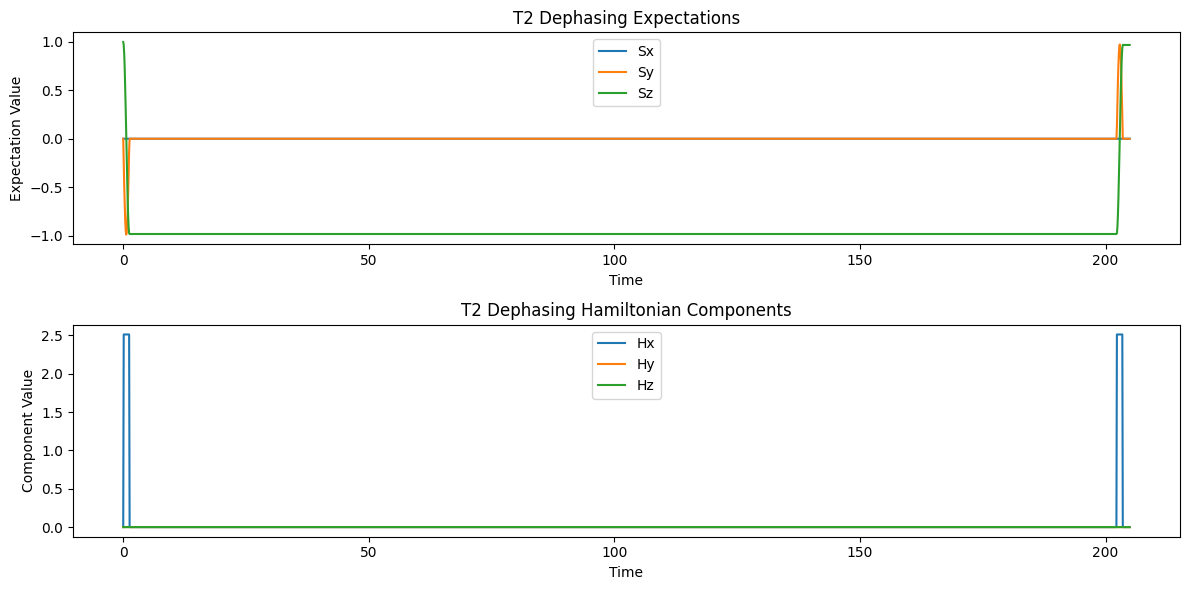

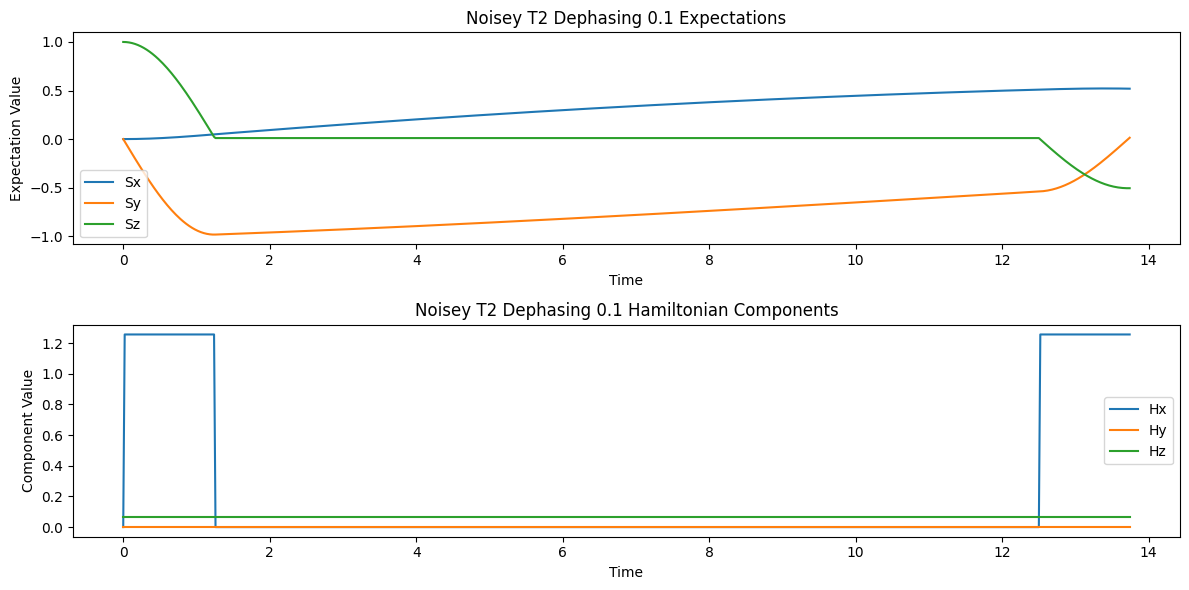

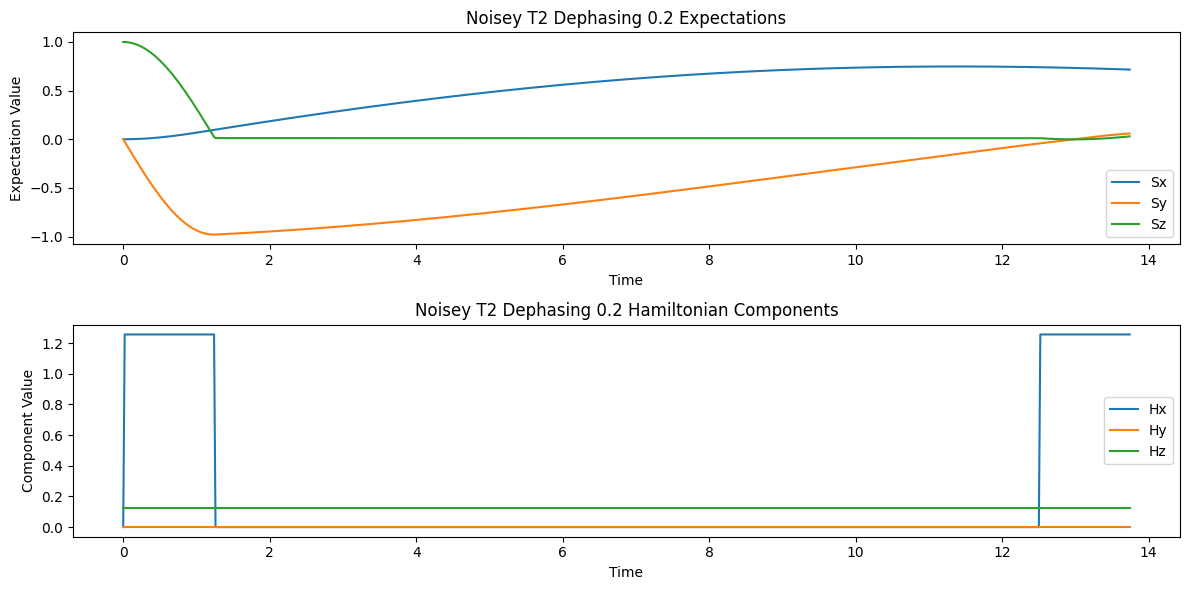

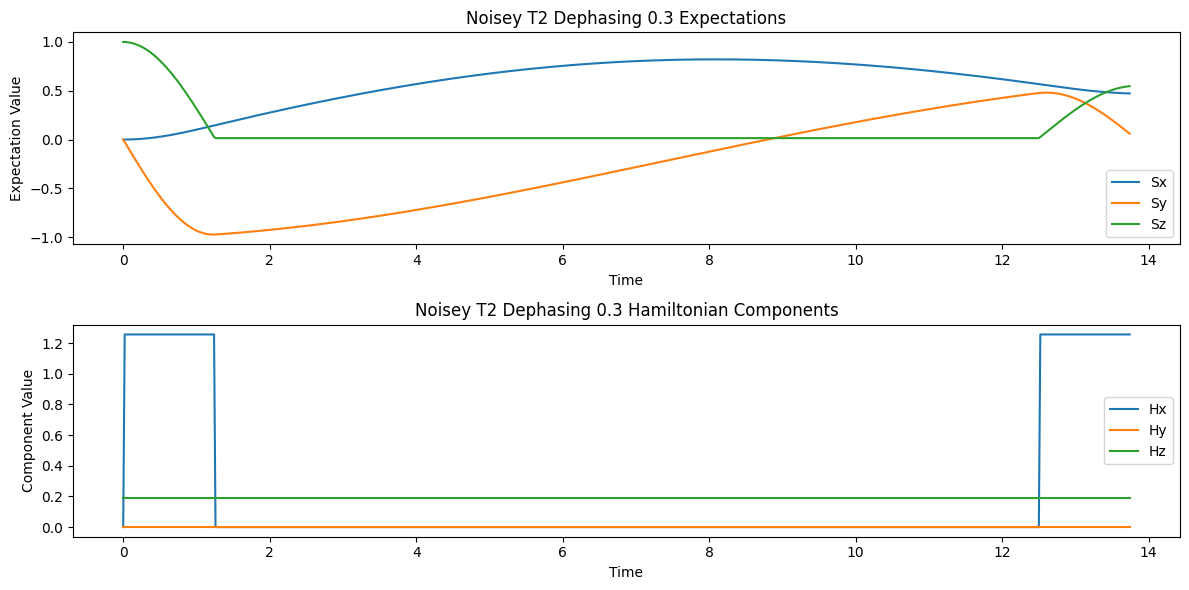

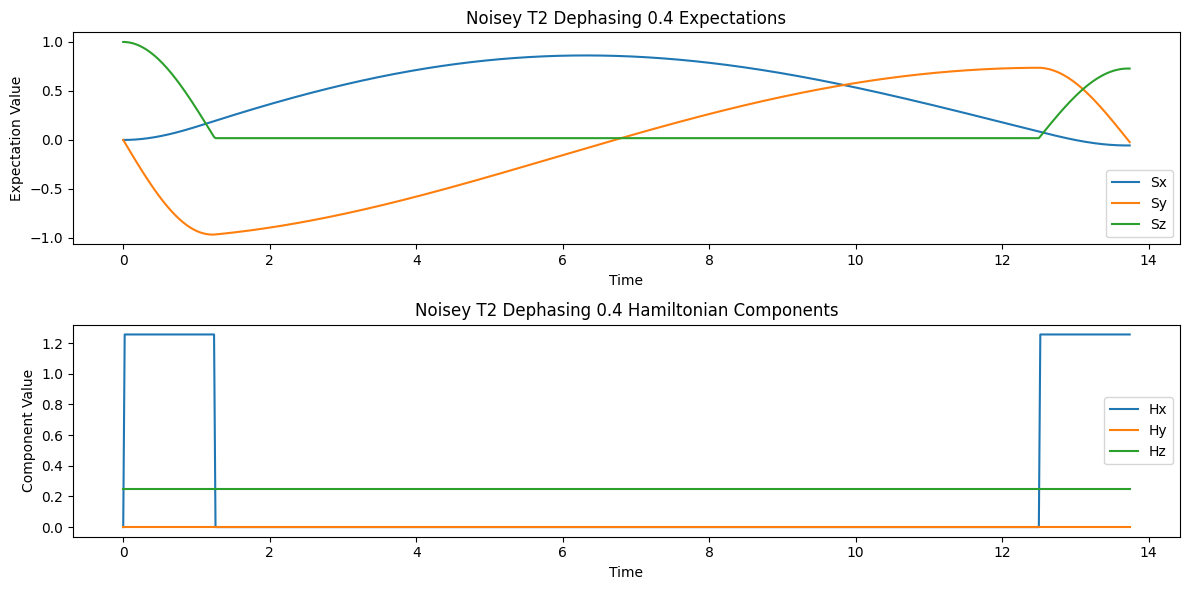

In [15]:
for system in SimParams:
    save_results(system['Name'])